# Fetching Financial Data with `yfinance`

## What is an API?

An **API (Application Programming Interface)** is a way for your code to talk to an external service and request data. Instead of manually downloading CSV files from a website, an API lets you write a few lines of code and get live, structured data delivered directly into your Python environment.

## What is `yfinance`?

`yfinance` is a Python library that acts as a wrapper around **Yahoo Finance's API**. It lets you pull:
- Historical stock prices
- Financial statements (income statement, balance sheet, cash flow)
- Corporate actions (dividends, stock splits)
- Analyst recommendations
- And much more — all for free

By the end of this notebook, you will be able to pull real market data and start building your own financial analysis workflows.

---
## Step 1: Install `yfinance`

Before using any external library, you need to install it. The `!` at the start of the cell tells Jupyter to run this as a **terminal command** rather than Python code.

You only need to run this once per environment (e.g., once on Google Colab, or once when setting up your local machine).

In [ ]:
!pip install yfinance  # Install version 1.3.0 or later

---
## Step 2: Download Historical Price Data

### Method 1 — Single Ticker

`yf.download()` is the quickest way to fetch historical **OHLCV data** for a stock:

| Column | Meaning |
|--------|---------------------------|
| **Open** | Price at market open |
| **High** | Highest price of the day |
| **Low** | Lowest price of the day |
| **Close** | Price at market close |
| **Volume** | Number of shares traded |

The result is a **pandas DataFrame**, which is the standard data structure for tabular data in Python — think of it as a spreadsheet you can manipulate with code.

**Key parameters:**
- `start` / `end` — date range in `YYYY-MM-DD` format
- `period` — shorthand alternative (e.g. `"1mo"`, `"6mo"`, `"1y"`, `"max"`)
- `interval` — data frequency: `"1d"` (daily), `"1wk"` (weekly), `"1mo"` (monthly)

In [1]:
import yfinance as yf

# Download daily OHLCV data for Tesla between two specific dates
# "TSLA" is Tesla's stock ticker symbol on NASDAQ
tsla = yf.download("TSLA", start="2026-01-01", end="2026-05-15")

# .head() shows the first 5 rows — useful for a quick sanity check
print(tsla.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            TSLA        TSLA        TSLA        TSLA      TSLA
Date                                                                
2026-01-02  438.070007  458.339996  435.299988  457.799988  85535400
2026-01-05  451.670013  457.549988  444.570007  447.989990  67940800
2026-01-06  432.959991  448.250000  428.779999  446.380005  89093800
2026-01-07  431.410004  438.369995  431.290009  435.899994  59828800
2026-01-08  435.799988  436.890015  424.369995  427.890015  57041100


---
### Method 2 — Multiple Tickers (Portfolio)

You can pass a **list of ticker symbols** to download data for several stocks in a single API call. This is useful when analysing a portfolio or comparing companies.

When downloading multiple tickers, `yfinance` returns a DataFrame with a **two-level (MultiIndex) column structure**:
- The **top level** is the data type (e.g., `Close`, `Open`, `Volume`)
- The **second level** is the ticker symbol

Think of it as several DataFrames stacked side by side.

In [2]:
# Download the last 1 month of data for three large-cap tech stocks
# period="1mo" is a convenient shorthand — no need to specify exact dates
portfolio = yf.download(["AAPL", "MSFT", "GOOG"], period="1mo")

[*********************100%***********************]  3 of 3 completed


#### Exploring the MultiIndex structure

When working with a new dataset, always inspect its structure first. `.keys()` shows the column labels so you know exactly how to access each piece of data.

In [3]:
# Shows all (data_type, ticker) column pairs in the DataFrame
portfolio.keys()

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'GOOG'),
            ( 'Close', 'MSFT'),
            (  'High', 'AAPL'),
            (  'High', 'GOOG'),
            (  'High', 'MSFT'),
            (   'Low', 'AAPL'),
            (   'Low', 'GOOG'),
            (   'Low', 'MSFT'),
            (  'Open', 'AAPL'),
            (  'Open', 'GOOG'),
            (  'Open', 'MSFT'),
            ('Volume', 'AAPL'),
            ('Volume', 'GOOG'),
            ('Volume', 'MSFT')],
           names=['Price', 'Ticker'])

In [4]:
# Access the 'Close' slice — a DataFrame with one column per ticker
# This is what you'll use most often for return calculations and charting
print(portfolio['Close'].head())

Ticker            AAPL        GOOG        MSFT
Date                                          
2026-05-04  276.575165  379.640015  412.726074
2026-05-05  283.918427  384.269989  410.490936
2026-05-06  287.245361  395.140015  413.065338
2026-05-07  287.175415  395.299988  419.860626
2026-05-08  293.050018  397.049988  414.222839


---
## Step 3: Visualise Closing Prices

Visualisation is essential in finance — a chart can reveal trends, volatility, and correlations that are hard to spot in raw numbers.

We use **matplotlib**, Python's standard plotting library. Since the `Close` slice is already a tidy DataFrame (dates as index, one column per stock), pandas lets us call `.plot()` directly on it.

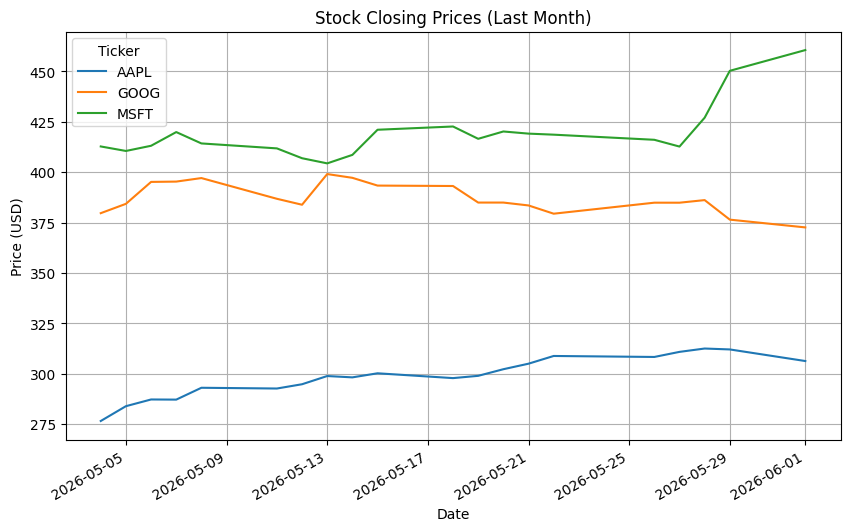

In [5]:
import matplotlib.pyplot as plt

# Plot closing prices for all three tickers on a single chart
# figsize=(width, height) controls the chart dimensions in inches
portfolio['Close'].plot(figsize=(10, 6))

# Chart labels and formatting
plt.title('Stock Closing Prices (Last Month)')
plt.ylabel('Price (USD)')
plt.xlabel('Date')
plt.grid(True)  # Gridlines make it easier to read values

plt.show()

#### Accessing a single stock's closing prices

To drill down to one company within the multi-ticker DataFrame, chain two square-bracket selectors: first the data type, then the ticker symbol.

In [6]:
# Extract Apple's closing prices as a pandas Series
# Syntax: portfolio['data_type']['TICKER']
print(portfolio['Close']['AAPL'].head())

Date
2026-05-04    276.575165
2026-05-05    283.918427
2026-05-06    287.245361
2026-05-07    287.175415
2026-05-08    293.050018
Name: AAPL, dtype: float64


---
## Step 4: Company Fundamentals with the `Ticker` Object

### What is the `Ticker` object?

While `yf.download()` is optimised for price series, the **`yf.Ticker()`** object gives you access to a much richer set of company-specific data:

| Attribute | What it returns |
|---|---|
| `.info` | Company profile, valuation metrics, market cap, etc. |
| `.financials` | Annual income statement |
| `.balance_sheet` | Annual balance sheet |
| `.cashflow` | Annual cash flow statement |
| `.dividends` | Historical dividend payments |
| `.splits` | Historical stock splits |
| `.recommendations` | Analyst buy/sell/hold ratings |

This is the foundation for **fundamental analysis** — evaluating a company's intrinsic value based on its financial health.

In [7]:
# Create a Ticker object for Apple Inc.
# This doesn't fetch data yet — it just creates a handle to query later
aapl = yf.Ticker("AAPL")

# .info returns a dictionary with dozens of fields about the company
# .get('field') is safer than ['field'] — returns None instead of crashing if a key is missing
info = aapl.info

print(f"Company:  {info.get('longName')}")
print(f"Sector:   {info.get('sector')}")
print(f"Industry: {info.get('industry')}")

Company:  Apple Inc.
Sector:   Technology
Industry: Consumer Electronics




---
## Step 5: Corporate Actions — Dividends & Stock Splits

**Corporate actions** are events that change a company's stock or financial structure:

- **Dividends** — cash payments made to shareholders from company profits. A key signal of financial health and shareholder-friendly management.
- **Stock splits** — a company increases its share count (e.g., 2-for-1 split), lowering the price per share proportionally. The total market cap does not change, but it can affect liquidity and investor accessibility.

> **Why this matters:** When calculating historical returns, you must adjust for splits and dividends. Unadjusted price data will show artificial drops on ex-dividend dates. `yfinance` provides **adjusted close prices** by default.

In [8]:
# Retrieve Apple's full dividend history as a pandas Series (date → amount)
dividends = aapl.dividends

# Retrieve Apple's stock split history as a pandas Series (date → split ratio)
splits = aapl.splits

print("Dividends (USD per share):")
print(dividends)
print("-" * 40)
print("Stock Splits (ratio):")
print(splits)

Dividends (USD per share):
Date
1987-05-11 09:30:00-04:00    0.000536
1987-08-10 09:30:00-04:00    0.000536
1987-11-17 09:30:00-05:00    0.000714
1988-02-12 09:30:00-05:00    0.000714
1988-05-16 09:30:00-04:00    0.000714
                               ...   
2025-05-12 09:30:00-04:00    0.260000
2025-08-11 09:30:00-04:00    0.260000
2025-11-10 09:30:00-05:00    0.260000
2026-02-09 09:30:00-05:00    0.260000
2026-05-11 09:30:00-04:00    0.270000
Name: Dividends, Length: 91, dtype: float64
----------------------------------------
Stock Splits (ratio):
Date
1987-06-16 09:30:00-04:00    2.0
2000-06-21 09:30:00-04:00    2.0
2005-02-28 09:30:00-05:00    2.0
2014-06-09 09:30:00-04:00    7.0
2020-08-31 09:30:00-04:00    4.0
Name: Stock Splits, dtype: float64


---
## Step 6: Financial Statements

The **three core financial statements** are the backbone of fundamental analysis:

| Statement | What it tells you |
|---|---|
| **Income Statement** (`.financials`) | Revenue, costs, and profit over a period |
| **Balance Sheet** (`.balance_sheet`) | What the company owns (assets) vs. owes (liabilities) at a point in time |
| **Cash Flow Statement** (`.cashflow`) | Actual cash generated and spent — less susceptible to accounting manipulation than net income |

`yfinance` returns these as DataFrames where:
- **Rows** are line items (e.g., Total Revenue, Net Income)
- **Columns** are fiscal years (most recent first)

In [9]:
# Annual Income Statement
# .iloc[:, :2] selects ALL rows but only the 2 most recent columns (fiscal years)
# This keeps the output readable — Apple's full income statement has many line items
income_stmt = aapl.financials
print("Income Statement (2 most recent fiscal years):")
print(income_stmt.iloc[:, :2])

Income Statement (2 most recent fiscal years):
                                                      2025-09-30    2024-09-30
Tax Effect Of Unusual Items                         0.000000e+00  0.000000e+00
Tax Rate For Calcs                                  1.560000e-01  2.410000e-01
Normalized EBITDA                                   1.447480e+11  1.346610e+11
Net Income From Continuing Operation Net Minori...  1.120100e+11  9.373600e+10
Reconciled Depreciation                             1.169800e+10  1.144500e+10
Reconciled Cost Of Revenue                          2.209600e+11  2.103520e+11
EBITDA                                              1.447480e+11  1.346610e+11
EBIT                                                1.330500e+11  1.232160e+11
Net Interest Income                                          NaN           NaN
Interest Expense                                             NaN           NaN
Interest Income                                              NaN           NaN
Norma

In [10]:
# Annual Balance Sheet
balance_sheet = aapl.balance_sheet

# Annual Cash Flow Statement
cash_flow = aapl.cashflow

In [12]:
# Try printing these yourself:
print(balance_sheet.iloc[:, :2])
print("----------------------------------")
print(cash_flow.iloc[:, :2])

                                                    2025-09-30    2024-09-30
Treasury Shares Number                                     NaN           NaN
Ordinary Shares Number                            1.477326e+10  1.511679e+10
Share Issued                                      1.477326e+10  1.511679e+10
Net Debt                                          6.272300e+10  7.668600e+10
Total Debt                                        9.865700e+10  1.066290e+11
...                                                        ...           ...
Cash Cash Equivalents And Short Term Investments  5.469700e+10  6.517100e+10
Other Short Term Investments                      1.876300e+10  3.522800e+10
Cash And Cash Equivalents                         3.593400e+10  2.994300e+10
Cash Equivalents                                  7.667000e+09  2.744000e+09
Cash Financial                                    2.826700e+10  2.719900e+10

[69 rows x 2 columns]
----------------------------------
                  

---
## Step 7: Analyst Recommendations

Investment banks and research firms publish **buy/hold/sell ratings** on stocks. These are aggregated by Yahoo Finance and accessible via `.recommendations`.

The DataFrame shows:
- **Period** — how recent the data is (e.g., `0m` = current month)
- **strongBuy, buy, hold, sell, strongSell** — number of analysts with each rating

> **Important caveat:** Analyst recommendations are a **lagging indicator** and come with conflicts of interest (investment banks may have relationships with the companies they rate). Use them as one data point among many, not as a trading signal.

In [13]:
# Retrieve a summary of analyst recommendations
# Returns a DataFrame showing buy/hold/sell counts by time period
recommendations = aapl.recommendations
recommendations

,period,strongBuy,buy,hold,sell,strongSell
0,0m,7,23,15,1,2
1,-1m,7,23,15,1,2
2,-2m,7,25,14,1,1
3,-3m,6,25,15,1,1


---
## Summary

Here's what you learned in this notebook:

| Concept | Code |
|---|---|
| Download single-stock price history | `yf.download("TSLA", start=..., end=...)` |
| Download multi-stock portfolio data | `yf.download(["AAPL", "MSFT"], period="1mo")` |
| Access a specific data type | `portfolio['Close']` |
| Plot closing prices | `portfolio['Close'].plot()` |
| Get company fundamentals | `yf.Ticker("AAPL").info` |
| Get financial statements | `.financials`, `.balance_sheet`, `.cashflow` |
| Get corporate actions | `.dividends`, `.splits` |
| Get analyst ratings | `.recommendations` |

### Next Steps
- Calculate **daily returns**: `portfolio['Close'].pct_change()`
- Calculate **cumulative returns**: `(1 + returns).cumprod()`
- Build a **correlation matrix**: `portfolio['Close'].corr()`
- Compute financial ratios (P/E, P/B) from `.info` fields